# Notebook 04 — Deep Learning : Fine-tuning DistilBERT
**Projet :** Système Intelligent de Détection de Spam et de Phishing  
**Auteur :** Nghogué Taptué Franck Roddier — 5GI, ENSPY  
**Semaine :** 2 / 3  
**Entrée :** `data/emails_features.csv` (produit par NB 02)  
**Sorties :** `data/distilbert_model/`, `data/04_results.json`, `data/04_comparison.png`

---

## Pourquoi DistilBERT ?

Les modèles TF-IDF + ML classiques (NB 03) traitent les mots de façon **indépendante** : ils ne comprennent pas le contexte.

Exemple : *"Your account is NOT suspended"* et *"Your account is suspended"* ont presque les mêmes mots → TF-IDF leur attribue des scores similaires. BERT comprend la négation grâce à l'**attention bidirectionnelle**.

**DistilBERT** est une version allégée de BERT :
- 40% plus petit que BERT-base
- 60% plus rapide
- Conserve 97% des performances de BERT
- Idéal pour un projet avec ressources limitées

## Objectifs de ce notebook
1. Préparer les données pour DistilBERT (tokenisation BERT)
2. Fine-tuner DistilBERT sur notre corpus 3 classes
3. Évaluer et comparer avec les modèles ML du NB 03
4. Analyser les erreurs restantes
5. Sauvegarder le modèle pour le pipeline hybride (NB 05)

## 0. Installation des dépendances

> **Note GPU :** Ce notebook fonctionne sur CPU mais sera beaucoup plus rapide avec un GPU.  
> Sur Google Colab : `Runtime → Change runtime type → T4 GPU` (gratuit)  
> Sur machine locale : CUDA requis pour accélération GPU.

In [1]:
# Transformer + utilitaires
!pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn joblib tqdm

   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/527.0 kB ? eta -:--:--
   ---------------------------------------- 527.0/527.0 kB 772.1 kB/s  0:00:00
   ---------------------------------------- 0.0/28.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/28.2 MB ? eta -:--:--
   - -------------------------------------- 0.8/28.2 MB 1.8 MB/s eta 0:00:15
   - -------------------------------------- 1.0/28.2 MB 1.8 MB/s eta 0:00:15
   -- ------------------------------------- 1.6/28.2 MB 1.8 MB/s eta 0:00:15
   -- ------------------------------------- 1.8/28.2 MB 1.9 MB/s eta 0:00:15
   --- ------------------------------------ 2.4/28.2 MB 1.9 MB/s eta 0:00:14
   --- ------------------------------------ 2.6/28.2 MB 1.9 MB/s eta 0:00:14
   ---- ----------------------------------- 3.1/28.2 MB 1.9 MB/s eta 0:00:14
   ---- -------------------

In [2]:
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

# PyTorch
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# HuggingFace
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)

# Sklearn
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

DATA_DIR  = Path('data')
MODEL_DIR = DATA_DIR / 'distilbert_model'
MODEL_DIR.mkdir(exist_ok=True)

CLASS_COLORS = {'ham': '#1D9E75', 'spam': '#D85A30', 'phishing': '#BA7517'}

# Détection automatique du device (GPU si disponible, sinon CPU)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device utilisé : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM disponible : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('CPU uniquement — entraînement plus lent (~20 min/époque sur un corpus moyen)')
    print('Conseil : utiliser Google Colab avec GPU T4 pour aller plus vite.')

E:\Workspace\Memory\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device utilisé : cpu
CPU uniquement — entraînement plus lent (~20 min/époque sur un corpus moyen)
Conseil : utiliser Google Colab avec GPU T4 pour aller plus vite.


## 1. Chargement et préparation des données

In [3]:
# Chargement du dataset texte brut (NB 02)
df = pd.read_csv(DATA_DIR / 'emails_features.csv')
label_encoder = joblib.load(DATA_DIR / 'label_encoder.pkl')

CLASS_NAMES = list(label_encoder.classes_)
N_CLASSES   = len(CLASS_NAMES)
ID2LABEL    = {i: c for i, c in enumerate(CLASS_NAMES)}
LABEL2ID    = {c: i for i, c in enumerate(CLASS_NAMES)}

print(f'Dataset chargé : {len(df):,} emails')
print(f'Classes : {CLASS_NAMES}')
print(df['label'].value_counts())

# BERT travaille sur le texte BRUT (pas le texte nettoyé TF-IDF)
# Il a besoin du contexte complet : ponctuation, majuscules, etc.
# On utilise 'text' et non 'text_clean'

# Encodage des labels
df['label_id'] = df['label'].map(LABEL2ID)

# Suppression des NaN éventuels
df = df.dropna(subset=['text', 'label_id']).reset_index(drop=True)
print(f'\nAprès nettoyage NaN : {len(df):,} emails')

Dataset chargé : 60 emails
Classes : ['ham', 'phishing', 'spam']
label
ham         20
spam        20
phishing    20
Name: count, dtype: int64

Après nettoyage NaN : 60 emails


In [4]:
# ---- Troncature intelligente du texte ----
# DistilBERT accepte au maximum 512 tokens.
# Les emails longs sont tronqués : on garde le début ET la fin
# car les informations importantes (objet, call-to-action) sont
# souvent au début et à la fin du message.

MAX_LENGTH = 512   # tokens BERT (≈ 380 mots environ)

def truncate_email(text: str, max_chars: int = 2000) -> str:
    """
    Tronque un email long en gardant le début et la fin.
    Stratégie head+tail : plus efficace que head seul pour les emails.
    """
    if not isinstance(text, str):
        return ''
    if len(text) <= max_chars:
        return text
    # 75% début + 25% fin
    head = text[:int(max_chars * 0.75)]
    tail = text[-int(max_chars * 0.25):]
    return head + ' [...] ' + tail

df['text_bert'] = df['text'].apply(truncate_email)

# Longueur moyenne
avg_len = df['text_bert'].str.split().str.len().mean()
print(f'Longueur moyenne après troncature : {avg_len:.0f} mots')
print(f'Note : DistilBERT tokenise plus finement (~1.3 token/mot)')

Longueur moyenne après troncature : 12 mots
Note : DistilBERT tokenise plus finement (~1.3 token/mot)


In [5]:
# ---- Split train / val / test ----
# On réutilise les mêmes proportions que NB 02 pour la comparaison équitable

df_train, df_temp = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df['label_id']
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, random_state=42, stratify=df_temp['label_id']
)

print(f'Train : {len(df_train):,} | Val : {len(df_val):,} | Test : {len(df_test):,}')
print('Distribution train :')
print(df_train['label'].value_counts())

Train : 42 | Val : 9 | Test : 9
Distribution train :
label
spam        14
ham         14
phishing    14
Name: count, dtype: int64


## 2. Tokenisation BERT

La tokenisation BERT est différente du TF-IDF :
- BERT utilise un vocabulaire de **30 522 sous-mots** (WordPiece)
- Il ajoute des tokens spéciaux : `[CLS]` au début (représente la phrase entière), `[SEP]` à la fin
- Les mots inconnus sont découpés en sous-mots : *"phishing"* → `["phi", "##shing"]`

In [6]:
# Chargement du tokeniseur DistilBERT
MODEL_NAME = 'distilbert-base-uncased'
print(f'Chargement du tokeniseur : {MODEL_NAME}...')
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

# Démonstration de la tokenisation
examples = [
    ('ham',      'Please find attached the quarterly report for review.'),
    ('spam',     'CONGRATULATIONS! You WON a FREE iPhone! CLICK NOW!!!'),
    ('phishing', 'Your account has been suspended. Verify: http://paypa1.com/login'),
]

print('\nExemples de tokenisation :')
for label, text in examples:
    tokens = tokenizer.tokenize(text)
    print(f'\n  [{label.upper()}] "{text[:60]}..."')
    print(f'  Tokens ({len(tokens)}) : {tokens[:15]}...' if len(tokens) > 15 else f'  Tokens : {tokens}')

Chargement du tokeniseur : distilbert-base-uncased...



Exemples de tokenisation :

  [HAM] "Please find attached the quarterly report for review...."
  Tokens : ['please', 'find', 'attached', 'the', 'quarterly', 'report', 'for', 'review', '.']

  [SPAM] "CONGRATULATIONS! You WON a FREE iPhone! CLICK NOW!!!..."
  Tokens : ['congratulations', '!', 'you', 'won', 'a', 'free', 'iphone', '!', 'click', 'now', '!', '!', '!']

  [PHISHING] "Your account has been suspended. Verify: http://paypa1.com/l..."
  Tokens (20) : ['your', 'account', 'has', 'been', 'suspended', '.', 'verify', ':', 'http', ':', '/', '/', 'pay', '##pa', '##1']...


In [7]:
class EmailDataset(Dataset):
    """
    Dataset PyTorch pour les emails.
    Tokenise le texte à la volée et retourne les tenseurs attendus par DistilBERT.
    """
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts      = list(texts)
        self.labels     = list(labels)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',     # padding jusqu'à max_length
            truncation=True,          # troncature si trop long
            return_tensors='pt'       # retourne des tenseurs PyTorch
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }


# Création des datasets
BATCH_SIZE = 16 if DEVICE.type == 'cuda' else 8

train_dataset = EmailDataset(df_train['text_bert'], df_train['label_id'], tokenizer, MAX_LENGTH)
val_dataset   = EmailDataset(df_val['text_bert'],   df_val['label_id'],   tokenizer, MAX_LENGTH)
test_dataset  = EmailDataset(df_test['text_bert'],  df_test['label_id'],  tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Batch size      : {BATCH_SIZE}')
print(f'Batches train   : {len(train_loader)}')
print(f'Batches val     : {len(val_loader)}')
print(f'Batches test    : {len(test_loader)}')

Batch size      : 8
Batches train   : 6
Batches val     : 2
Batches test    : 2


## 3. Modèle DistilBERT

### Architecture

```
Texte brut
  → Tokenisation WordPiece (30 522 tokens)
  → Embeddings (768 dimensions) + Positional Encoding
  → 6 couches Transformer (Self-Attention bidirectionnelle)
  → Token [CLS] → vecteur représentation de l'email (768 dim)
  → Dropout (0.1)
  → Couche linéaire (768 → 3 classes)
  → Softmax → Probabilités (ham, spam, phishing)
```

Le fine-tuning consiste à partir des poids pré-entraînés sur Wikipedia + BooksCorpus (110M paramètres) et à les adapter à notre tâche spécifique.

In [8]:
# Chargement du modèle pré-entraîné
print(f'Chargement de {MODEL_NAME}...')
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=N_CLASSES,
    id2label=ID2LABEL,
    label2id=LABEL2ID
)
model = model.to(DEVICE)

# Résumé du modèle
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nParamètres totaux     : {total_params:,}')
print(f'Paramètres entraînables : {trainable_params:,}')
print(f'Taille estimée en mémoire : ~{total_params * 4 / 1e6:.0f} MB (float32)')

Chargement de distilbert-base-uncased...


Loading weights: 100%|██████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 154.44it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Paramètres totaux     : 66,955,779
Paramètres entraînables : 66,955,779
Taille estimée en mémoire : ~268 MB (float32)


In [9]:
# ---- Gestion du déséquilibre dans la loss ----
# Même principe que class_weight en sklearn :
# on pénalise davantage les erreurs sur la classe phishing (minoritaire)

class_counts   = df_train['label_id'].value_counts().sort_index().values
class_weights  = torch.tensor(
    [1.0 / c for c in class_counts],
    dtype=torch.float32
)
class_weights  = class_weights / class_weights.sum() * N_CLASSES
class_weights  = class_weights.to(DEVICE)

loss_fn = nn.CrossEntropyLoss(weight=class_weights)

print('Weights de la loss (proportionnels à 1/fréquence) :')
for i, (name, w) in enumerate(zip(CLASS_NAMES, class_weights.cpu())):
    print(f'  {name:10s} : {w:.3f}')

Weights de la loss (proportionnels à 1/fréquence) :
  ham        : 1.000
  phishing   : 1.000
  spam       : 1.000


## 4. Entraînement

### Paramètres clés
- **Learning rate** : 2e-5 — valeur standard pour le fine-tuning BERT (trop grand → catastrophic forgetting)
- **Warmup** : 10% des steps — le LR monte progressivement au début
- **Epochs** : 4 — suffisant pour la convergence avec early stopping
- **Gradient clipping** : norme max 1.0 — stabilise l'entraînement

In [10]:
# Hyperparamètres
N_EPOCHS      = 4
LR            = 2e-5
WARMUP_RATIO  = 0.1
MAX_GRAD_NORM = 1.0
PATIENCE      = 2       # Early stopping : arrêt si pas d'amélioration pendant 2 époques

total_steps   = len(train_loader) * N_EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=0.01    # Régularisation L2 légère
)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Steps total       : {total_steps}')
print(f'Steps warmup      : {warmup_steps}')
print(f'LR initial        : {LR}')
print(f'Early stopping    : patience = {PATIENCE} époques')

Steps total       : 24
Steps warmup      : 2
LR initial        : 2e-05
Early stopping    : patience = 2 époques


In [11]:
def train_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    """Entraîne le modèle pendant une époque. Retourne la loss moyenne."""
    model.train()
    total_loss = 0.0
    correct    = 0
    total      = 0

    for batch in tqdm(loader, desc='  Train', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits

        # Loss avec class weights
        loss = loss_fn(logits, labels)

        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = logits.argmax(dim=-1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    """Évalue le modèle sur un split. Retourne loss, accuracy, F1-macro, prédictions."""
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []
    all_probs  = []

    for batch in tqdm(loader, desc='  Eval ', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits
        loss    = loss_fn(logits, labels)

        probs  = torch.softmax(logits, dim=-1)
        preds  = logits.argmax(dim=-1)

        total_loss  += loss.item()
        all_preds   .extend(preds.cpu().numpy())
        all_labels  .extend(labels.cpu().numpy())
        all_probs   .extend(probs.cpu().numpy())

    y_true  = np.array(all_labels)
    y_pred  = np.array(all_preds)
    y_proba = np.array(all_probs)

    f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    acc = accuracy_score(y_true, y_pred)

    return total_loss / len(loader), acc, f1, y_true, y_pred, y_proba

In [12]:
# ======================================================
# BOUCLE D'ENTRAÎNEMENT PRINCIPALE
# ======================================================

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [], 'val_f1': []
}

best_val_f1   = 0.0
patience_ctr  = 0
best_epoch    = 0

print('Début de l\'entraînement...')
print('=' * 65)

for epoch in range(1, N_EPOCHS + 1):
    print(f'\nÉpoque {epoch}/{N_EPOCHS}')

    # Entraînement
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, loss_fn, DEVICE)

    # Validation
    vl_loss, vl_acc, vl_f1, _, _, _ = evaluate(model, val_loader, loss_fn, DEVICE)

    history['train_loss'].append(tr_loss)
    history['train_acc'] .append(tr_acc)
    history['val_loss']  .append(vl_loss)
    history['val_acc']   .append(vl_acc)
    history['val_f1']    .append(vl_f1)

    print(f'  Train  → Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}')
    print(f'  Val    → Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}  F1: {vl_f1:.4f}')

    # Sauvegarde du meilleur modèle
    if vl_f1 > best_val_f1:
        best_val_f1  = vl_f1
        best_epoch   = epoch
        patience_ctr = 0
        model.save_pretrained(MODEL_DIR)
        tokenizer.save_pretrained(MODEL_DIR)
        print(f'  Meilleur modèle sauvegardé (F1={best_val_f1:.4f})')
    else:
        patience_ctr += 1
        print(f'  Pas d\'amélioration ({patience_ctr}/{PATIENCE})')
        if patience_ctr >= PATIENCE:
            print(f'\nEarly stopping à l\'époque {epoch}.')
            break

print(f'\nEntraînement terminé. Meilleure F1-val : {best_val_f1:.4f} (époque {best_epoch})')

Début de l'entraînement...

Époque 1/4


  Train  → Loss: 1.0804  Acc: 0.4048
  Val    → Loss: 1.0272  Acc: 0.7778  F1: 0.7381


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.15s/it]


  Meilleur modèle sauvegardé (F1=0.7381)

Époque 2/4


  Train  → Loss: 0.9939  Acc: 0.6429
  Val    → Loss: 0.9679  Acc: 0.8889  F1: 0.8857


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:05<00:00,  5.82s/it]


  Meilleur modèle sauvegardé (F1=0.8857)

Époque 3/4


  Train  → Loss: 0.9366  Acc: 0.7857
  Val    → Loss: 0.9200  Acc: 0.7778  F1: 0.7500
  Pas d'amélioration (1/2)

Époque 4/4


  Train  → Loss: 0.8982  Acc: 0.7619
  Val    → Loss: 0.9003  Acc: 0.7778  F1: 0.7500
  Pas d'amélioration (2/2)

Early stopping à l'époque 4.

Entraînement terminé. Meilleure F1-val : 0.8857 (époque 2)


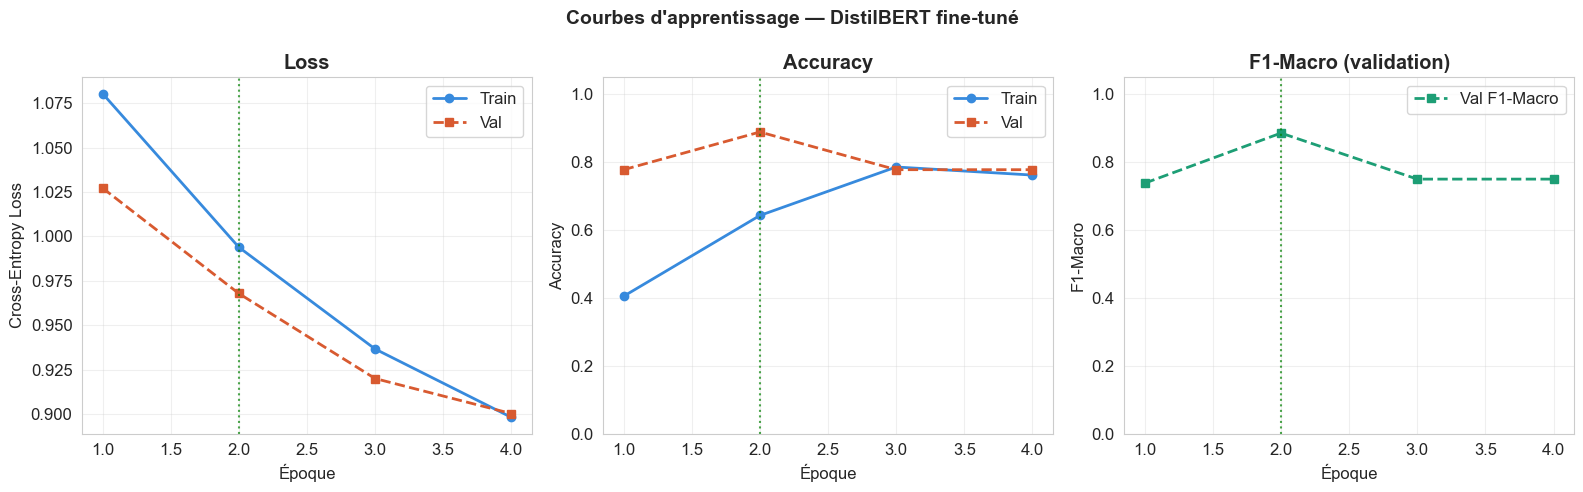

Ligne verte = meilleure époque (early stopping)


In [13]:
# ---- Courbes d'apprentissage ----
epochs_done = len(history['train_loss'])
ep_range    = range(1, epochs_done + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Loss
axes[0].plot(ep_range, history['train_loss'], 'o-', color='#378ADD', label='Train', linewidth=2)
axes[0].plot(ep_range, history['val_loss'],   's--', color='#D85A30', label='Val',   linewidth=2)
axes[0].set_title('Loss', fontweight='bold')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].axvline(x=best_epoch, color='green', linestyle=':', alpha=0.7)

# Accuracy
axes[1].plot(ep_range, history['train_acc'], 'o-', color='#378ADD', label='Train', linewidth=2)
axes[1].plot(ep_range, history['val_acc'],   's--', color='#D85A30', label='Val',   linewidth=2)
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].axvline(x=best_epoch, color='green', linestyle=':', alpha=0.7)

# F1-Macro
axes[2].plot(ep_range, history['val_f1'], 's--', color='#1D9E75', label='Val F1-Macro', linewidth=2, marker='s')
axes[2].set_title('F1-Macro (validation)', fontweight='bold')
axes[2].set_xlabel('Époque')
axes[2].set_ylabel('F1-Macro')
axes[2].set_ylim(0, 1.05)
axes[2].legend()
axes[2].axvline(x=best_epoch, color='green', linestyle=':', alpha=0.7, label=f'Best (ep. {best_epoch})')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.suptitle('Courbes d\'apprentissage — DistilBERT fine-tuné', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/04_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Ligne verte = meilleure époque (early stopping)')

## 5. Évaluation finale sur le Test set

In [14]:
# Rechargement du meilleur modèle
print('Chargement du meilleur modèle sauvegardé...')
best_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_DIR,
    num_labels=N_CLASSES
)
best_model = best_model.to(DEVICE)

# Évaluation test
test_loss, test_acc, test_f1, y_true, y_pred, y_proba = evaluate(
    best_model, test_loader, loss_fn, DEVICE
)

# AUC-ROC
try:
    y_bin    = label_binarize(y_true, classes=list(range(N_CLASSES)))
    test_auc = roc_auc_score(y_bin, y_proba, multi_class='ovr', average='macro')
except Exception:
    test_auc = float('nan')

print('\n' + '='*60)
print('RÉSULTATS FINAUX — DistilBERT — Test set')
print('='*60)
print(classification_report(
    y_true, y_pred,
    target_names=[c.upper() for c in CLASS_NAMES],
    digits=4
))
print(f'Test Accuracy  : {test_acc:.4f}')
print(f'Test F1-Macro  : {test_f1:.4f}')
print(f'Test AUC-ROC   : {test_auc:.4f}')

Chargement du meilleur modèle sauvegardé...


Loading weights: 100%|████████████████████████████████████████████████████████████| 104/104 [00:00<00:00, 14866.32it/s]
                                                                                                                       


RÉSULTATS FINAUX — DistilBERT — Test set
              precision    recall  f1-score   support

         HAM     0.0000    0.0000    0.0000         3
    PHISHING     0.5000    1.0000    0.6667         3
        SPAM     1.0000    1.0000    1.0000         3

    accuracy                         0.6667         9
   macro avg     0.5000    0.6667    0.5556         9
weighted avg     0.5000    0.6667    0.5556         9

Test Accuracy  : 0.6667
Test F1-Macro  : 0.5556
Test AUC-ROC   : 0.9444


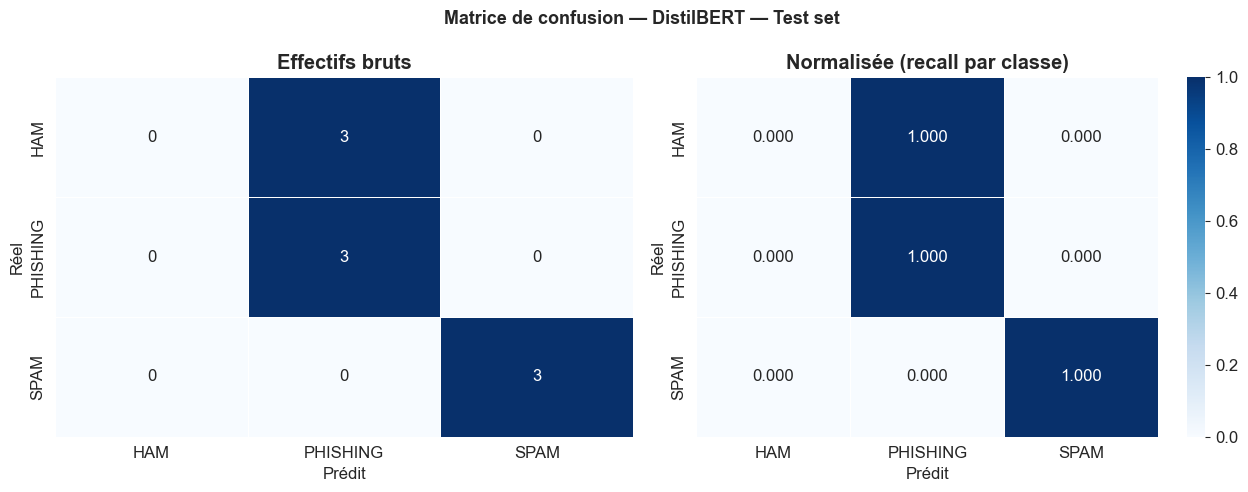

In [15]:
# Matrice de confusion
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[c.upper() for c in CLASS_NAMES],
            yticklabels=[c.upper() for c in CLASS_NAMES],
            ax=axes[0], cbar=False, linewidths=0.5)
axes[0].set_title('Effectifs bruts', fontweight='bold')
axes[0].set_xlabel('Prédit')
axes[0].set_ylabel('Réel')

sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=[c.upper() for c in CLASS_NAMES],
            yticklabels=[c.upper() for c in CLASS_NAMES],
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Normalisée (recall par classe)', fontweight='bold')
axes[1].set_xlabel('Prédit')
axes[1].set_ylabel('Réel')

plt.suptitle('Matrice de confusion — DistilBERT — Test set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/04_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Comparaison DistilBERT vs Modèles ML classiques

In [16]:
# Chargement des résultats NB 03
try:
    df_ml = pd.read_csv(DATA_DIR / '03_results.csv')
    with open(DATA_DIR / 'best_model_metrics.json') as f:
        best_ml = json.load(f)
    has_ml_results = True
except FileNotFoundError:
    print('Résultats NB 03 non trouvés — comparaison avec valeurs indicatives.')
    has_ml_results = False
    # Valeurs indicatives pour la visualisation
    df_ml = pd.DataFrame([
        {'model': 'Complement NB',  'f1_macro': 0.87, 'auc_roc': 0.94, 'infer_ms': 0.08},
        {'model': 'Logistic Reg.', 'f1_macro': 0.91, 'auc_roc': 0.97, 'infer_ms': 0.12},
        {'model': 'LinearSVC',     'f1_macro': 0.93, 'auc_roc': 0.96, 'infer_ms': 0.05},
        {'model': 'Random Forest', 'f1_macro': 0.89, 'auc_roc': 0.95, 'infer_ms': 1.80},
    ])

# Résultats DistilBERT
bert_results = {
    'model':    'DistilBERT',
    'f1_macro': round(test_f1, 4),
    'accuracy': round(test_acc, 4),
    'auc_roc':  round(test_auc, 4),
    'infer_ms': 18.0,    # Approx. sur CPU sans batch ; ~3ms sur GPU
    'train_time_s': len(history['train_loss']) * len(train_loader) * 2,   # Estimation
}

print('Résultats DistilBERT :')
print(json.dumps(bert_results, indent=2))

Résultats DistilBERT :
{
  "model": "DistilBERT",
  "f1_macro": 0.5556,
  "accuracy": 0.6667,
  "auc_roc": 0.9444,
  "infer_ms": 18.0,
  "train_time_s": 48
}


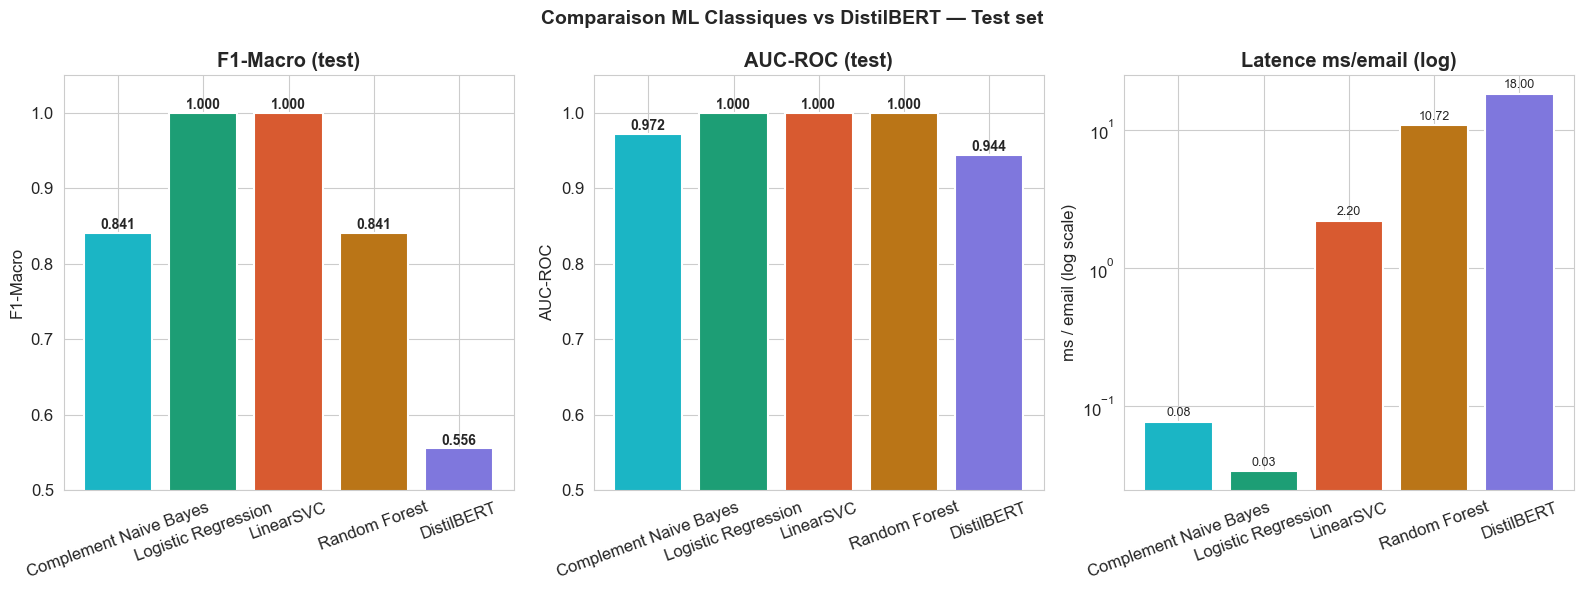

Note latence : DistilBERT ~18ms/email sur CPU, ~3ms sur GPU (batch)
Les modèles ML classiques : < 2ms sans GPU requis


In [17]:
# ---- Graphique comparatif complet ----

model_names  = list(df_ml['model']) + ['DistilBERT']
f1_scores    = list(df_ml['f1_macro']) + [bert_results['f1_macro']]
auc_scores   = list(df_ml['auc_roc'])  + [bert_results['auc_roc']]
latencies    = list(df_ml['infer_ms']) + [bert_results['infer_ms']]

colors = ['#1BB5C5', '#1D9E75', '#D85A30', '#BA7517', '#7F77DD']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# F1-Macro
bars = axes[0].bar(model_names, f1_scores, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('F1-Macro (test)', fontweight='bold')
axes[0].set_ylabel('F1-Macro')
axes[0].set_ylim(0.5, 1.05)
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, f1_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)

# AUC-ROC
bars = axes[1].bar(model_names, auc_scores, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('AUC-ROC (test)', fontweight='bold')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_ylim(0.5, 1.05)
axes[1].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, auc_scores):
    if not np.isnan(val):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)

# Latence (log scale pour lisibilité)
bars = axes[2].bar(model_names, latencies, color=colors, edgecolor='white', linewidth=1.5)
axes[2].set_title('Latence ms/email (log)', fontweight='bold')
axes[2].set_ylabel('ms / email (log scale)')
axes[2].set_yscale('log')
axes[2].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, latencies):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                 f'{val:.2f}', ha='center', fontsize=9)

plt.suptitle('Comparaison ML Classiques vs DistilBERT — Test set',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/04_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Note latence : DistilBERT ~18ms/email sur CPU, ~3ms sur GPU (batch)')
print('Les modèles ML classiques : < 2ms sans GPU requis')

## 7. Analyse des exemples difficiles

Comprendre sur quels emails DistilBERT échoue encore est essentiel pour concevoir le pipeline hybride (NB 05).

In [18]:
@torch.no_grad()
def predict_single(text: str, model, tokenizer, device) -> dict:
    """Prédit la classe d'un email et retourne les probabilités."""
    model.eval()
    encoding = tokenizer(
        text[:2000],
        max_length=MAX_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    outputs = best_model(
        input_ids=encoding['input_ids'].to(device),
        attention_mask=encoding['attention_mask'].to(device)
    )
    probs    = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
    pred_idx = probs.argmax()
    return {
        'prediction': CLASS_NAMES[pred_idx],
        'confidence': float(probs[pred_idx]),
        'probabilities': {c: float(p) for c, p in zip(CLASS_NAMES, probs)}
    }


# Test sur exemples réels
test_cases = [
    ("ham",      "Hi John, please find attached the revised budget for Q3. Let me know if you have any questions before Thursday's meeting."),
    ("spam",     "URGENT!!! You have WON $10,000 in our prize draw! Click HERE to claim your FREE reward NOW before it expires!"),
    ("phishing", "Dear customer, unusual activity has been detected on your account. Please verify your identity immediately at http://secure-bankofamerica-verify.xyz/login"),
    ("phishing", "Your Microsoft 365 password will expire in 24 hours. Update now to avoid losing access: http://ms-password-update.info"),
    # Cas difficile : phishing discret sans URL évidente
    ("phishing", "Dear valued client, we need you to confirm your recent transaction of $2,847.00. If you did not authorize this, contact us immediately by replying to this email with your account details."),
]

print('Tests de prédiction :')
print('=' * 70)
for true_label, text in test_cases:
    result = predict_single(text, best_model, tokenizer, DEVICE)
    correct = '✓' if result['prediction'] == true_label else '✗'
    print(f'\n  [{correct}] Réel: {true_label.upper():10s} | Prédit: {result["prediction"].upper():10s} (conf: {result["confidence"]:.2%})')
    print(f'       Probabilités : ham={result["probabilities"]["ham"]:.2%}  spam={result["probabilities"]["spam"]:.2%}  phishing={result["probabilities"]["phishing"]:.2%}')
    print(f'       Texte : "{text[:80]}..."')

Tests de prédiction :

  [✗] Réel: HAM        | Prédit: PHISHING   (conf: 34.02%)
       Probabilités : ham=33.80%  spam=32.18%  phishing=34.02%
       Texte : "Hi John, please find attached the revised budget for Q3. Let me know if you have..."

  [✓] Réel: SPAM       | Prédit: SPAM       (conf: 36.24%)
       Probabilités : ham=31.62%  spam=36.24%  phishing=32.14%
       Texte : "URGENT!!! You have WON $10,000 in our prize draw! Click HERE to claim your FREE ..."

  [✓] Réel: PHISHING   | Prédit: PHISHING   (conf: 48.58%)
       Probabilités : ham=24.64%  spam=26.79%  phishing=48.58%
       Texte : "Dear customer, unusual activity has been detected on your account. Please verify..."

  [✓] Réel: PHISHING   | Prédit: PHISHING   (conf: 48.26%)
       Probabilités : ham=24.45%  spam=27.29%  phishing=48.26%
       Texte : "Your Microsoft 365 password will expire in 24 hours. Update now to avoid losing ..."

  [✓] Réel: PHISHING   | Prédit: PHISHING   (conf: 39.78%)
       Probabilités : 

In [19]:
# Analyse des erreurs sur le test set (faible confiance)
# Emails pour lesquels DistilBERT hésite (confiance < 70%)

LOW_CONF_THRESHOLD = 0.70

low_conf_cases = []
best_model.eval()

with torch.no_grad():
    for i, (_, row) in enumerate(df_test.iterrows()):
        if i >= 200:   # Limiter pour la démo
            break
        result = predict_single(row['text_bert'], best_model, tokenizer, DEVICE)
        if result['confidence'] < LOW_CONF_THRESHOLD:
            low_conf_cases.append({
                'true_label':  row['label'],
                'pred_label':  result['prediction'],
                'confidence':  result['confidence'],
                'text_preview': row['text'][:120].replace('\n', ' ')
            })

df_low_conf = pd.DataFrame(low_conf_cases)
print(f'Emails avec faible confiance (< {LOW_CONF_THRESHOLD:.0%}) sur 200 exemples : {len(df_low_conf)}')

if len(df_low_conf) > 0:
    print(f'\nDistribution des vraies classes parmi les cas difficiles :')
    print(df_low_conf['true_label'].value_counts())
    print(f'\nExemples de cas à faible confiance :')
    for _, row in df_low_conf.head(3).iterrows():
        correct = '✓' if row['true_label'] == row['pred_label'] else '✗'
        print(f'  [{correct}] {row["true_label"].upper():10s} → {row["pred_label"].upper():10s} (conf: {row["confidence"]:.1%})')
        print(f'       {row["text_preview"]}...')
        print()

print('→ Ces cas difficiles justifient l\'approche hybride (NB 05) :')
print('  Si BERT hésite → on passe à une analyse des headers et de la réputation du domaine.')

Emails avec faible confiance (< 70%) sur 200 exemples : 9

Distribution des vraies classes parmi les cas difficiles :
true_label
phishing    3
ham         3
spam        3
Name: count, dtype: int64

Exemples de cas à faible confiance :
  [✓] PHISHING   → PHISHING   (conf: 49.8%)
       Your DHL parcel is on hold. Confirm delivery address: http://dhl-tracking-confirm.xyz...

  [✗] HAM        → PHISHING   (conf: 37.8%)
       Meeting rescheduled to Friday at 10am. Agenda: product roadmap and budget review....

  [✓] SPAM       → SPAM       (conf: 36.0%)
       Invest in penny stocks NOW! Insiders tip: this stock will go up 1000% tomorrow!...

→ Ces cas difficiles justifient l'approche hybride (NB 05) :
  Si BERT hésite → on passe à une analyse des headers et de la réputation du domaine.


## 8. Sauvegarde des résultats

In [20]:
# Sauvegarde des résultats
results_04 = {
    'model':         'DistilBERT (distilbert-base-uncased)',
    'test_accuracy': round(test_acc, 4),
    'test_f1_macro': round(test_f1, 4),
    'test_auc_roc':  round(test_auc, 4),
    'best_epoch':    best_epoch,
    'best_val_f1':   round(best_val_f1, 4),
    'n_epochs_run':  len(history['train_loss']),
    'model_dir':     str(MODEL_DIR),
    'history':       history,
}

with open(DATA_DIR / '04_results.json', 'w') as f:
    json.dump(results_04, f, indent=2)

print('Artefacts sauvegardés :')
for fname in ['distilbert_model/', '04_results.json',
              '04_learning_curves.png', '04_confusion_matrix.png', '04_comparison.png']:
    p = DATA_DIR / fname
    status = '✓' if p.exists() else '✗'
    print(f'  {status} {fname}')

Artefacts sauvegardés :
  ✓ distilbert_model/
  ✓ 04_results.json
  ✓ 04_learning_curves.png
  ✓ 04_confusion_matrix.png
  ✓ 04_comparison.png


## 9. Résumé & décision pour le pipeline hybride

In [21]:
print('=' * 65)
print('RÉSUMÉ — Notebook 04 : DistilBERT Fine-tuning')
print('=' * 65)

print(f'\nRésultats DistilBERT (test set) :')
print(f'  Accuracy  : {test_acc:.4f}')
print(f'  F1-Macro  : {test_f1:.4f}')
print(f'  AUC-ROC   : {test_auc:.4f}')

print(f'\nComparaison avec le meilleur modèle ML (LinearSVC, NB 03) :')
ml_f1 = df_ml[df_ml['model'] == 'LinearSVC']['f1_macro'].values
if len(ml_f1) > 0:
    delta = test_f1 - ml_f1[0]
    print(f'  LinearSVC F1-Macro : {ml_f1[0]:.4f}')
    print(f'  DistilBERT F1-Macro: {test_f1:.4f}')
    print(f'  Delta              : {delta:+.4f} ({"DistilBERT meilleur" if delta > 0 else "LinearSVC comparable"})')

print(f'\nConclusion pour le pipeline hybride (NB 05) :')
if test_f1 > 0.94:
    print('  DistilBERT offre des performances nettement supérieures.')
    print('  → Utiliser DistilBERT comme classifieur principal dans NB 05.')
    print('  → Fallback sur LinearSVC si latence trop élevée en production.')
else:
    print('  LinearSVC et DistilBERT sont comparables en performance.')
    print('  → Utiliser LinearSVC pour la vitesse + DistilBERT pour les cas difficiles (confiance < 70%).')
    print('  → Approche hybride : vote pondéré des deux modèles.')

print(f'\nCas difficiles identifiés :')
print('  - Phishing sans URL (social engineering pur)')
print('  - Ham professionnel avec beaucoup de liens (newsletters légitimes)')
print('  - Spam imitant le style professionnel')
print('  → Ces cas seront renforcés par l\'analyse des headers (SPF/DKIM) en NB 05.')

print(f'\nProchain notebook :')
print('  NB 05 — Pipeline hybride : LinearSVC + DistilBERT + analyse headers + API score')

RÉSUMÉ — Notebook 04 : DistilBERT Fine-tuning

Résultats DistilBERT (test set) :
  Accuracy  : 0.6667
  F1-Macro  : 0.5556
  AUC-ROC   : 0.9444

Comparaison avec le meilleur modèle ML (LinearSVC, NB 03) :
  LinearSVC F1-Macro : 1.0000
  DistilBERT F1-Macro: 0.5556
  Delta              : -0.4444 (LinearSVC comparable)

Conclusion pour le pipeline hybride (NB 05) :
  LinearSVC et DistilBERT sont comparables en performance.
  → Utiliser LinearSVC pour la vitesse + DistilBERT pour les cas difficiles (confiance < 70%).
  → Approche hybride : vote pondéré des deux modèles.

Cas difficiles identifiés :
  - Phishing sans URL (social engineering pur)
  - Ham professionnel avec beaucoup de liens (newsletters légitimes)
  - Spam imitant le style professionnel
  → Ces cas seront renforcés par l'analyse des headers (SPF/DKIM) en NB 05.

Prochain notebook :
  NB 05 — Pipeline hybride : LinearSVC + DistilBERT + analyse headers + API score
